In [110]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, classification_report
)
from scipy.sparse import hstack


In [111]:
# Cell 2: Load dataset
df = pd.read_csv('ml_resume_dataset_4500.csv')
df.head()

,id,name,years_experience,highest_degree,skills,current_title,has_portfolio,raw_text,label
0,1,Badhan Shah,9.0,Bachelors,"NLP, GPT",Customer Support,False,Sales professional with strong communication s...,0
1,2,Lamia Sarker,2.0,Masters,"PyTorch, CI/CD, Power BI, Data Visualization, AWS",Administrative Assistant,False,Sales professional with strong communication s...,0
2,3,Badhan Molla,2.0,Bachelors,"AWS, Flask, Machine Learning, Model Deployment...",Computer Vision Engineer,True,Research scientist with strong statistical bac...,1
3,4,Badhan Ahmed,9.0,Bachelors,"Hadoop, Feature Engineering, Docker Compose, O...",Data Entry Operator,True,Customer support representative with some Exce...,0
4,5,Rasel Siddiqui,10.0,Bachelors,"Speech Recognition, Tableau, Azure, TensorFlow",Customer Support,False,Content creator interested in data science but...,0


In [130]:
df.describe()

,id,years_experience,highest_degree,label,skill_count
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000
mean,2250.500000,4.437778,0.585111,0.300000,6.095778
std,1299.182435,3.653459,0.658084,0.458308,3.608100
min,1.000000,0.000000,0.000000,0.000000,2.000000
25%,1125.750000,1.000000,0.000000,0.000000,3.000000
50%,2250.500000,4.000000,0.000000,0.000000,5.000000
75%,3375.250000,7.000000,1.000000,1.000000,8.000000
max,4500.000000,15.000000,2.000000,1.000000,15.000000


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                4500 non-null   int64  
 1   name              4500 non-null   object 
 2   years_experience  4500 non-null   float64
 3   highest_degree    4500 non-null   int64  
 4   skills            4500 non-null   object 
 5   current_title     4500 non-null   object 
 6   has_portfolio     4500 non-null   bool   
 7   raw_text          4500 non-null   object 
 8   label             4500 non-null   int64  
 9   combined_text     4500 non-null   object 
 10  skill_count       4500 non-null   int64  
dtypes: bool(1), float64(1), int64(4), object(5)
memory usage: 356.1+ KB


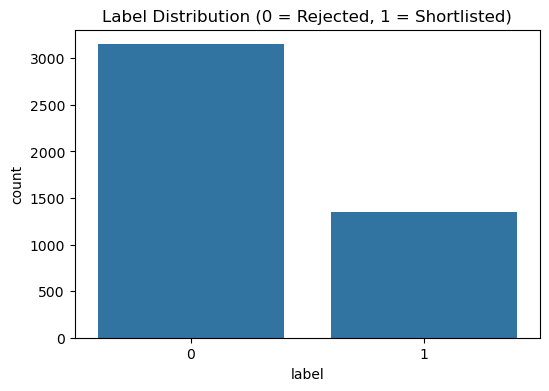

In [112]:
# Cell 3: Label distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['label'])
plt.title('Label Distribution (0 = Rejected, 1 = Shortlisted)')
plt.show()

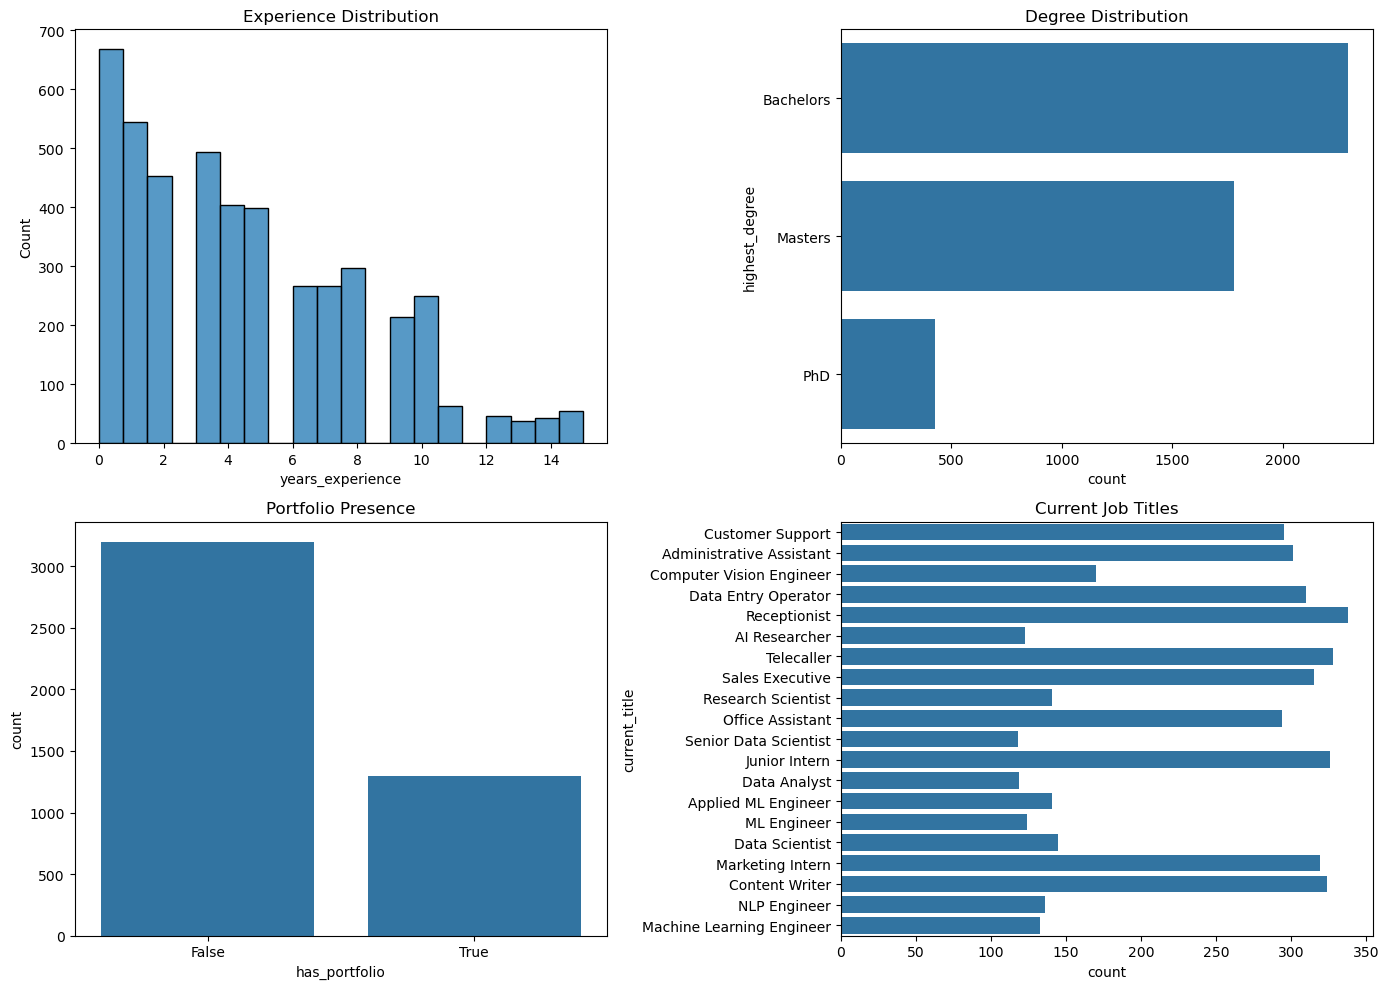

In [113]:
# Cell 4: Panel EDA
fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.histplot(df['years_experience'], bins=20, ax=axes[0,0])
axes[0,0].set_title('Experience Distribution')

sns.countplot(y=df['highest_degree'], ax=axes[0,1])
axes[0,1].set_title('Degree Distribution')

sns.countplot(x=df['has_portfolio'], ax=axes[1,0])
axes[1,0].set_title('Portfolio Presence')

sns.countplot(y=df['current_title'], ax=axes[1,1])
axes[1,1].set_title('Current Job Titles')

plt.tight_layout()
plt.show()

In [114]:
# Cell 5: Feature Engineering
df['combined_text'] = (
    df['raw_text'].fillna('') + ' ' +
    df['skills'].fillna('') + ' ' +
    df['current_title'].fillna('')
)

df['skill_count'] = df['skills'].apply(lambda x: len(str(x).split(',')))

degree_encoder = LabelEncoder()
df['highest_degree'] = degree_encoder.fit_transform(df['highest_degree'])

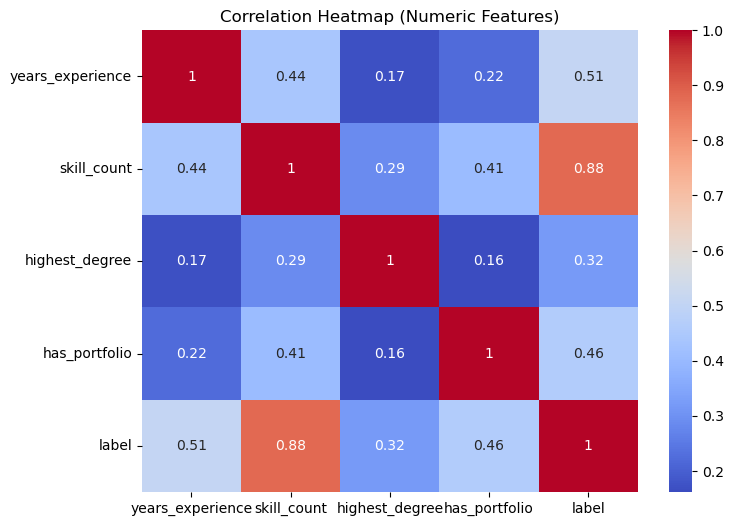

In [115]:
#cell 6 :correlation map 
plt.figure(figsize=(8,6))
corr = df[["years_experience","skill_count","highest_degree","has_portfolio","label"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

In [116]:
# Cell 7: Train-test split 
X_text = df['combined_text']
X_num = df[['years_experience', 'skill_count', 'highest_degree', 'has_portfolio']]
y = df['label']

X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_num, y, test_size=0.2, random_state=42, stratify=y
)

In [117]:
# Cell 8: TF-IDF + scaling

tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2))
X_text_train_tfidf = tfidf.fit_transform(X_text_train)
X_text_test_tfidf  = tfidf.transform(X_text_test)

scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled  = scaler.transform(X_num_test)

# Combine sparse text + numeric features
X_train = hstack([X_text_train_tfidf, X_num_train_scaled])
X_test  = hstack([X_text_test_tfidf, X_num_test_scaled])

In [118]:
# Cell 9: Train models
lr = LogisticRegression(max_iter=2000)
rf = RandomForestClassifier(n_estimators=200, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [119]:
# Cell 10: Model comparison
models = {'Logistic Regression': lr, 'Random Forest': rf}

for name, model in models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]
    print(f'\n{name}')
    print('Accuracy:', accuracy_score(y_test, preds))    
    print('ROC-AUC:', roc_auc_score(y_test, probs))


Logistic Regression
Accuracy: 1.0
ROC-AUC: 1.0

Random Forest
Accuracy: 1.0
ROC-AUC: 1.0


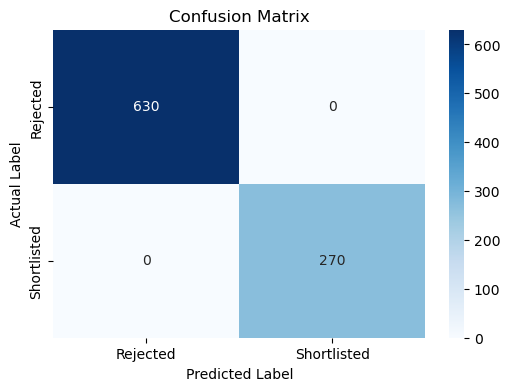

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       630
           1       1.00      1.00      1.00       270

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



In [120]:
#cell 11 :Confusion matrix
model = lr  # choose model here (lr or rf)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Rejected", "Shortlisted"],
    yticklabels=["Rejected", "Shortlisted"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

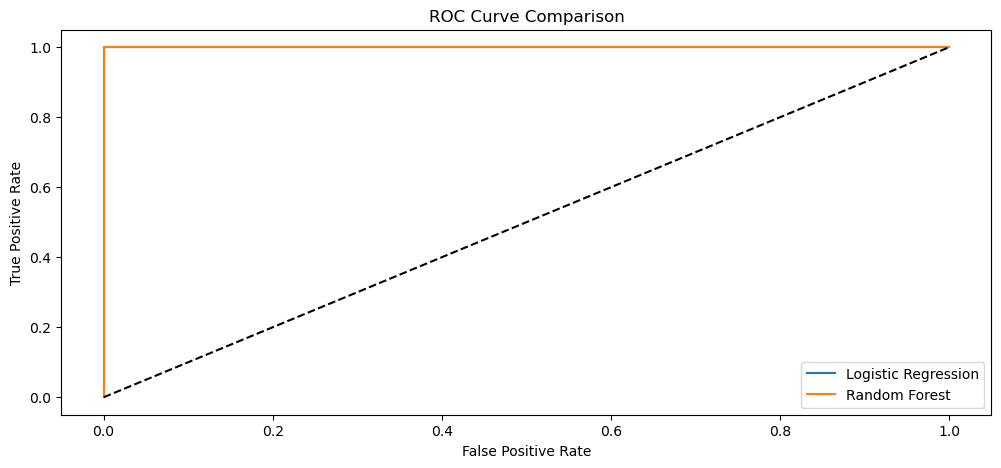

In [121]:
# Cell 12:  ROC curve
plt.figure(figsize=(12,5))

for name, model in models.items():
    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

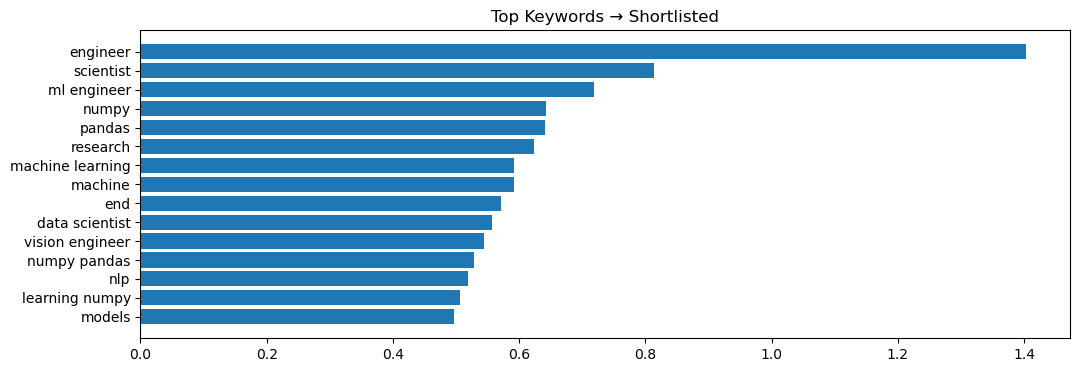

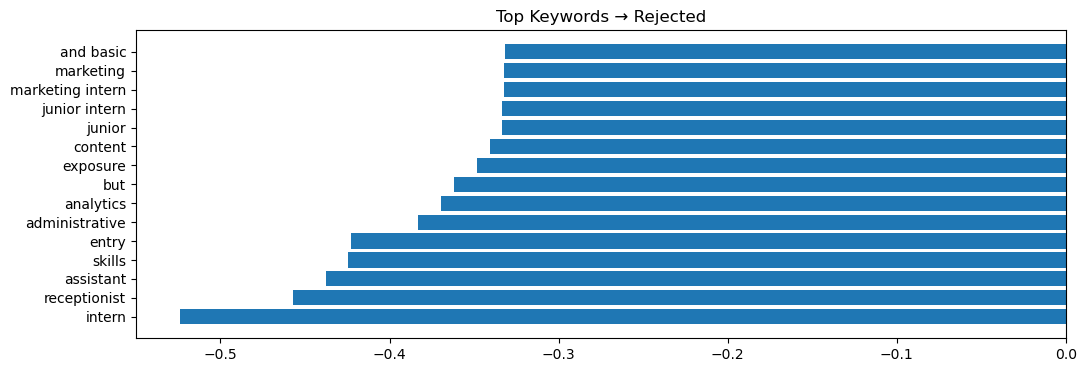

In [122]:
# Cell 13: Top keywords influencing shortlist vs reject
feature_names = np.array(tfidf.get_feature_names_out())
coef = lr.coef_[0][:len(feature_names)]

top_positive = feature_names[np.argsort(coef)[-15:]]
top_negative = feature_names[np.argsort(coef)[:15]]

plt.figure(figsize=(12,4))
plt.barh(top_positive, sorted(coef)[-15:])
plt.title('Top Keywords → Shortlisted')
plt.show()

plt.figure(figsize=(12,4))
plt.barh(top_negative, sorted(coef)[:15])
plt.title('Top Keywords → Rejected')
plt.show()

In [ ]:
# Cell 14: Predict single resume with probability visualization
def predict_resume(text, num_features):
    vec = tfidf.transform([text])
    num_scaled = scaler.transform([num_features])
    combined = hstack([vec, num_scaled])
    prob = lr.predict_proba(combined)[0]
    
    plt.bar(['Rejected','Shortlisted'], prob)
    plt.title('Resume Shortlist Probability')
    plt.show()
    
    return prob

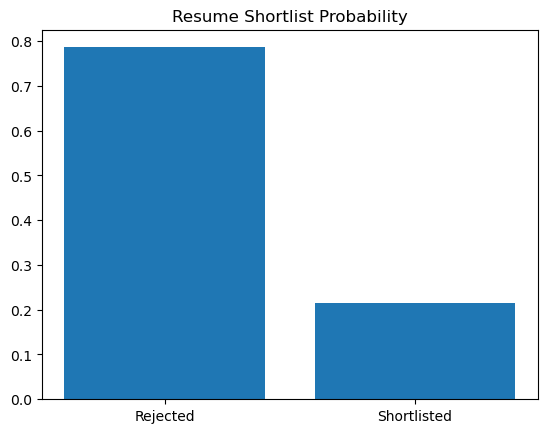

In [ ]:
#Example Usage
sample_text = "Python developer with 3 years experience in ML and NLP"
sample_numeric = [3, 6, 1, 1]  
# years_exp, skill_count, highest_degree, has_portfolio

predict_resume(sample_text, sample_numeric)

In [127]:
# Cell 15: Rank multiple candidates

def rank_candidates(df):
    df['degree_score'] = df['highest_degree'].map({
        'Bachelors': 1,
        'Masters': 2,
        'PhD': 3
    }).fillna(0)

    df['shortlist_score'] = (
        df['degree_score'] * 0.3 +
        df['years_experience'] * 0.4
    )

    return df.sort_values('shortlist_score', ascending=False)

In [128]:
# Cell 16: Score all resumes & show Top 10
df_scored = rank_candidates(df.copy())
df_scored[['current_title','shortlist_score']].head(10)

,current_title,shortlist_score
1782,Research Scientist,6.0
3263,NLP Engineer,6.0
4101,NLP Engineer,6.0
346,AI Researcher,6.0
2320,Research Scientist,6.0
2894,Computer Vision Engineer,6.0
4142,Research Scientist,6.0
888,Research Scientist,6.0
3864,Computer Vision Engineer,6.0
521,ML Engineer,6.0


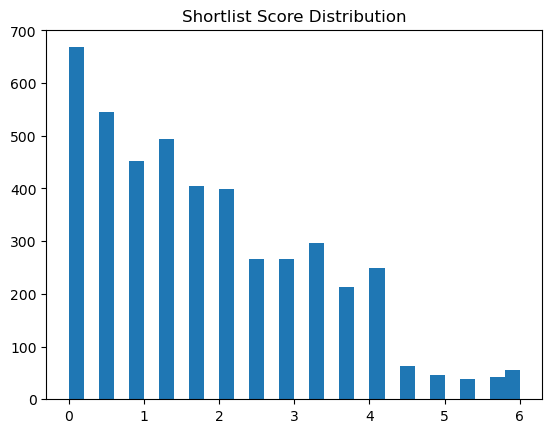

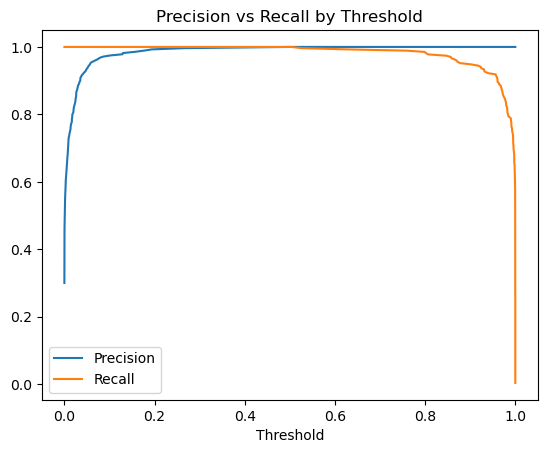

In [106]:
# Cell 17: Score distribution & Precision-Recall analysis
scores = df_scored['shortlist_score']

plt.hist(scores, bins=30)
plt.title('Shortlist Score Distribution')
plt.show()

precision, recall, thresholds = precision_recall_curve(y_test, lr.predict_proba(X_test)[:,1])
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.legend()
plt.title('Precision vs Recall by Threshold')
plt.xlabel('Threshold')
plt.show()